# Rolling relationship between gold returns and US treasury yields

## Research question
How has the relationship between gold and US10Y yields changed over time

## Hypothesis
The inverse relationship strengthened following the end of direct convertibility of the dollar. The Inverse relationship weakens again in the 2020s.

In [2]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

comparison = pd.read_csv('../data/processed/full_table.csv',index_col = 'Date', parse_dates = True)
time_frame = pd.DateOffset(years = 5)

In [3]:
def time_rolling_regression(df, time_window, x_label,y_label):
    coeffs = []
    intercepts = []
    r2score = []

    for i in pd.date_range(df.first_valid_index()+time_window, df.index[-1],freq = 'ME'):
        
        x_window = df[x_label].loc[i-time_window:i].to_frame()
        y_window = df[y_label].loc[i-time_window:i].to_frame()

        model = LinearRegression()
        model.fit(x_window, y_window)

        r2 = r2_score(y_window, model.predict(x_window))
        coeff = model.coef_
        intercept = model.intercept_
        
        coeffs.append(coeff[0][0])
        r2score.append(r2)
        intercepts.append(intercept[0])
        
    return coeffs, intercepts, r2score


nominal_coeffs, nominal_intercepts, nominal_r2score = time_rolling_regression(comparison, time_frame,'US10Y Yield (bp Change)', 'Gold Price (% Change)')


        

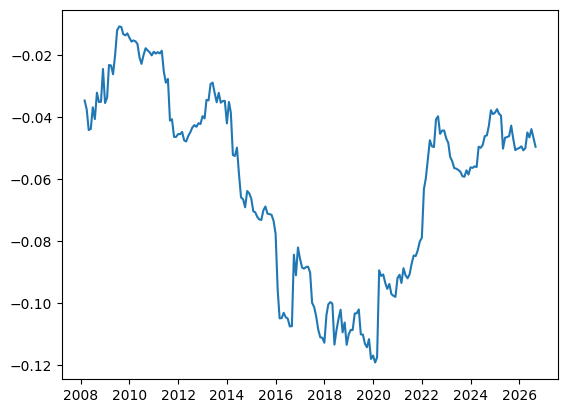

In [6]:
x_dates = pd.date_range(comparison.first_valid_index()+time_frame, comparison.index[-1], freq = 'ME').to_frame()
y_coeffs= pd.DataFrame(nominal_coeffs, columns = ['gradient'])
y_r2 = pd.DataFrame(nominal_r2score, columns = ['r2'])
plt.plot(x_dates,y_coeffs)


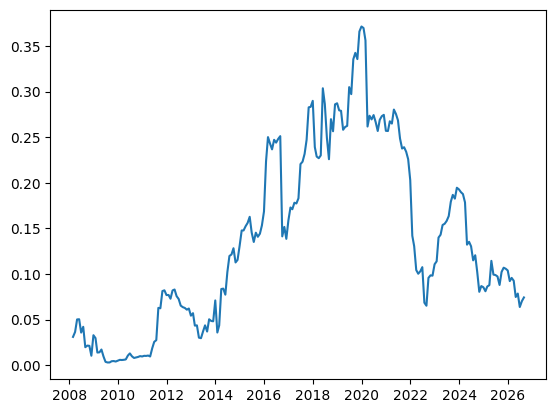

In [7]:
plt.plot(x_dates,y_r2)

In [1]:
#Validation
x_window = comparison['US10Y Yield (bp Change)'].loc[pd.Timestamp(year= 2000, month = 1, day = 31):pd.Timestamp(year = 2005, month = 1, day =31)].to_frame()
y_window = comparison['Gold Price (% Change)'].loc[pd.Timestamp(year= 2000, month = 1, day = 31):pd.Timestamp(year = 2005, month = 1, day =31)].to_frame()

validation = LinearRegression()
validation.fit(x_window,y_window)

print(validation.coef_,r2_score(y_window['Gold Price (% Change)'], validation.predict(x_window)))

i = pd.Timestamp(year= 2000, month = 1, day = 31)

x_label = 'US10Y Yield (bp Change)'
y_label = 'Gold Price (% Change)' 

x_window = comparison[x_label].loc[i:i+time_frame].to_frame()
y_window = comparison[y_label].loc[i:i+time_frame].to_frame()

model = LinearRegression()
model.fit(x_window, y_window)

print(model.coef_, r2_score(y_window, model.predict(x_window)))


print(x_window['US10Y Yield (bp Change)'].corr(y_window['Gold Price (% Change)'])**2)


NameError: name 'comparison' is not defined